# 1. Data collection

We started the project by collecting consumer reviews from Sephora. To achieve this, we performed two-step web scraping process:
1. **Product Catalog**: The first scraping step was done to retrieve the product URL and additional details for each product listed under the skincare category. This was done using the Constructor.io API that simplifies the scraping process compared to HTML parsing, which often breaks due to bot detection.
2. **Reviews**: The second step was done to retrieve reviews for each product using their product ID obtained from the first step. This was done using the Bazaarvoice API, that returns the results in a structured JSON format.

In [ ]:
## Product Catalog Scraper
from src.product_catalog_scraper import scrape_sephora_api

product_df = scrape_sephora_api(max_products=2900)

Products fetched:   0%|          | 0/2900 [00:00<?, ? products/s]

Page 49 returned 0 results — end of catalog.

Products saved to  	: sephora_skincare_products.csv
Total unique products	: 2859


In [ ]:
## Reviews Scraper
from src.reviews_scraper import scrape_all_reviews

reviews_df = scrape_all_reviews('sephora_skincare_products.csv')

Scraping reviews:  66%|██████▌   | 1890/2859 [4:17:42<1:11:20,  4.42s/ product] 
ERROR — P509413 (Canopy Showerhead Filters): Connection error at offset 0 — ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
Scraping reviews:  66%|██████▋   | 1896/2859 [4:33:52<14:54:26, 55.73s/ product] 
ERROR — P460515 (E-Rase™ Milki Micellar Water): Timed out at offset 500
Scraping reviews: 100%|██████████| 2859/2859 [5:38:35<00:00,  7.11s/ product]    

Done with errors.
Reviews saved to  : sephora_reviews.csv
Failed products   : 2  (see scrape_errors.log)
Re-run the script to retry failed products automatically.
Total reviews     : 1,710,285


# 2. Load Dataset

We saved the scraped results into a CSV file for reusability, and here we begin the project by loading the saved data into our notebook. We also perform an initial assessment to check the shape, data types, and distribution of the data we retrieved. We note the results for data preparation.

In [2]:
### Import library
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
# 1. Load data
product_df = pd.read_csv("./data/sephora_skincare_products.csv")

print(f"Product dataframe shape: {product_df.shape}")
display(product_df.head(3))

reviews_df = pd.read_csv("./data/sephora_reviews_cleaned.csv")

print(f"Reviews dataframe shape: {reviews_df.shape}")
display(reviews_df.head(3))

Product dataframe shape: (2859, 9)


,product_id,product_name,brand,price,rating,num_reviews,skin_type,skin_concern,product_link
0,P519160,Glazing Milk Ceramide Facial Essence,rhode,32.0,3.8430,1955.0,"comboSk, drySk, normalSk, oilySk","dryness, dullness, redness",https://www.sephora.com/product/glazing-milk-P519160
1,P427417,Niacinamide 10% + Zinc 1% Serum for Oily Skin,The Ordinary,6.0,4.2294,9000.0,"drySk, normalSk, oilySk","oiliness, pores",https://www.sephora.com/product/the-ordinary-deciem-niacinamide-10-zinc-1-P427417
2,P427406,Glycolic Acid 7% Exfoliating and Brightening Daily Toner,The Ordinary,13.5,4.3535,4549.0,"drySk, normalSk, oilySk",NaN,https://www.sephora.com/product/the-ordinary-deciem-glycolic-acid-7-toning-solution-P427406


Reviews dataframe shape: (1708512, 12)


,product_id,review_id,rating,review_title,review_text,timestamp,reviewer_nickname,cleaned_review_title,cleaned_review_text,cleaned_demojize_review_title,cleaned_demojize_review_text,year
0,P519160,382076916,5,A must have for me,It’s so good and moisturizing that sometimes I use it as a moisturizer. I don’t need anything else. I’m on my 5th bottle and I love this so much. I even use it on my body.,2026-03-19 19:12:57+00:00,Melanie803,a must have for me,it is so good and moisturizing that sometimes i use it as a moisturizer. i do not need anything else. i am on my 5th bottle and i love this so much. i even use it on my body.,a must have for me,it is so good and moisturizing that sometimes i use it as a moisturizer. i do not need anything else. i am on my 5th bottle and i love this so much. i even use it on my body.,2026
1,P519160,382016339,5,Must have every day routine,"I’m genuinely OBSESSED with this glazing milk 🤍 The texture is just everything—so lightweight, silky, and it melts into my skin instantly. It feels like a drink of water for my face every single time I use it.\n\nI keep it in my skincare fridge (yes, it’s that serious 😭) and using it cold makes the experience even better. It leaves my skin feeling SO smooth, like actual silk, and gives me that healthy, glowy finish without feeling heavy or greasy.\n\nI use it every single day and I’m not even kidding when I say I can’t go without it anymore. My skin just looks and feels so hydrated, calm, and fresh.\n\n10/10. I’m in love 💫",2026-03-18 22:50:31+00:00,Mariaa2499,must have every day routine,"i am genuinely obsessed with this glazing milk the texture is just everything—so lightweight, silky, and it melts into my skin instantly. it feels like a drink of water for my face every single time i use it. i keep it in my skincare fridge (yes, it is that serious ) and using it cold makes the experience even better. it leaves my skin feeling so smooth, like actual silk, and gives me that healthy, glowy finish without feeling heavy or greasy. i use it every single day and i am not even kidding when i say i cannot go without it anymore. my skin just looks and feels so hydrated, calm, and fresh. /. i am in love",must have every day routine,"i am genuinely obsessed with this glazing milk white heart the texture is just everything—so lightweight, silky, and it melts into my skin instantly. it feels like a drink of water for my face every single time i use it. i keep it in my skincare fridge (yes, it is that serious loudly crying face ) and using it cold makes the experience even better. it leaves my skin feeling so smooth, like actual silk, and gives me that healthy, glowy finish without feeling heavy or greasy. i use it every single day and i am not even kidding when i say i cannot go without it anymore. my skin just looks and feels so hydrated, calm, and fresh. /. i am in love dizzy",2026
2,P519160,381996695,1,Horrible,I had such high hopes for this product and was very disappointed in the outcome. I was looking for something I could use as a base before putting on makeup that would help with creating a glowy effect. My makeup would shift throughout the day and be patchy and honestly had never looked worse. I highly do not recommend using this product if you were planning on using it underneath makeup. Such a disappointment and waste of money!!,2026-03-18 18:03:09+00:00,Meron90,horrible,i had such high hopes for this product and was very disappointed in the outcome. i was looking for something i could use as a base before putting on makeup that would help with creating a glowy effect. my makeup would shift throughout the day and be patchy and honestly had never looked worse. i highly do not recommend using this product if you were planning on using it underneath makeup. such a disappointment and waste of money!!,horrible,i had such high hopes for this product and was very disappointed in the outcome. i was looking for something i could use as a base before putting on makeup that 

In [3]:
# 2. Check for data type and missing values
summary_product = pd.DataFrame({
    "data_type": product_df.dtypes,
    "missing_values": product_df.isnull().sum()
})

summary_reviews = pd.DataFrame({
    "data_type": reviews_df.dtypes,
    "missing_values": reviews_df.isnull().sum()
})

print("Product dataframe summary:")
display(summary_product)

print("Reviews dataframe summary:")
display(summary_reviews)

Product dataframe summary:


,data_type,missing_values
product_id,object,0
product_name,object,0
brand,object,1
price,float64,0
rating,float64,1
num_reviews,float64,1
skin_type,object,526
skin_concern,object,529
product_link,object,0


Reviews dataframe summary:


,data_type,missing_values
product_id,object,0
review_id,int64,0
rating,int64,0
review_title,object,429717
review_text,object,1752
timestamp,object,0
reviewer_nickname,object,20201


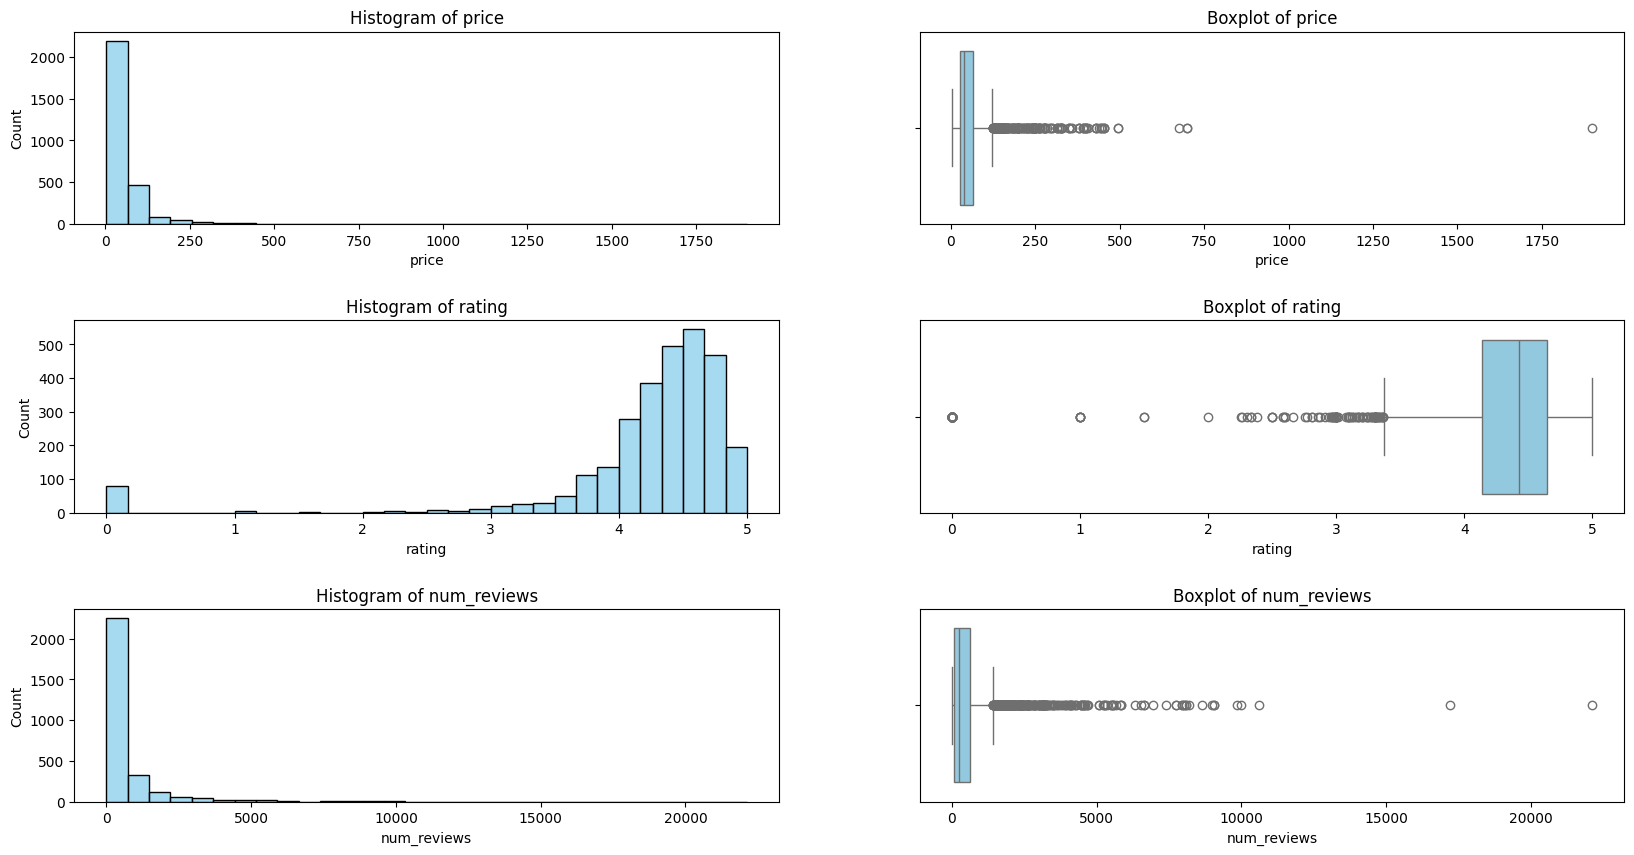

In [15]:
# 3. Distribution in numerical features

numeric_features = ['price', 'rating', 'num_reviews']

fig, axes = plt.subplots(len(numeric_features), 2, figsize=(20, 10))

for n, feat in enumerate(numeric_features):
    color = "skyblue"

    # Histogram
    sns.histplot(product_df[feat], bins=30, kde=False, color=color, ax=axes[n, 0])
    axes[n, 0].set_title(f'Histogram of {feat}')

    # Boxplot
    sns.boxplot(x=product_df[feat], color=color, ax=axes[n, 1])
    axes[n, 1].set_title(f'Boxplot of {feat}')
    
plt.subplots_adjust(hspace=0.5)
plt.show()

# 3. Data Preparation

In this section, we apply text preprocessing to gain a better understanding of the text data we have, and to bring it into a better state for extracting insights. We implement several steps based on our initial observations of the text characteristics. Here are the processes we performed:
1. Remove HTML tags
2. Remove URLs
3. Convert text to lowercase
4. Expand contractions
5. Convert emojis into interpretable text
6. Remove punctuation (optional)
7. Remove stopwords (optional)

Punctuation and stopwords may be excluded during modelling, as their removal can potentially cause the text to lose its genuine meaning. However, for exploratory visualisation, it is often beneficial to exclude common or unnecessary information in order to gain more meaningful insights.

In [ ]:
# Apply text preprocessing to the review_text column
from src.text_preprocessing import text_preprocessing_pipeline

pd.set_option('display.max_colwidth', None)

# Clean review titles
reviews_df['cleaned_review_title'] = reviews_df['review_title'].apply(lambda x: text_preprocessing_pipeline(x, emoji_mode="remove", remove_punctuation=False, remove_stopwords=False))

# Clean review texts, exploring both options for emoji handling
reviews_df['cleaned_review_text'] = reviews_df['review_text'].apply(lambda x: text_preprocessing_pipeline(x, emoji_mode="remove", remove_punctuation=False, remove_stopwords=False))
reviews_df['cleaned_demojize_review_text'] = reviews_df['review_text'].apply(lambda x: text_preprocessing_pipeline(x, emoji_mode="convert", remove_punctuation=False, remove_stopwords=False))

reviews_df[['review_text', 'cleaned_demojize_review_text']].head(3)

,review_text,cleaned_demojize_review_text
0,It’s so good and moisturizing that sometimes I use it as a moisturizer. I don’t need anything else. I’m on my 5th bottle and I love this so much. I even use it on my body.,it is so good and moisturizing that sometimes i use it as a moisturizer. i do not need anything else. i am on my 5th bottle and i love this so much. i even use it on my body.
1,"I’m genuinely OBSESSED with this glazing milk 🤍 The texture is just everything—so lightweight, silky, and it melts into my skin instantly. It feels like a drink of water for my face every single time I use it.\n\nI keep it in my skincare fridge (yes, it’s that serious 😭) and using it cold makes the experience even better. It leaves my skin feeling SO smooth, like actual silk, and gives me that healthy, glowy finish without feeling heavy or greasy.\n\nI use it every single day and I’m not even kidding when I say I can’t go without it anymore. My skin just looks and feels so hydrated, calm, and fresh.\n\n10/10. I’m in love 💫","i am genuinely obsessed with this glazing milk white heart the texture is just everything—so lightweight, silky, and it melts into my skin instantly. it feels like a drink of water for my face every single time i use it. i keep it in my skincare fridge (yes, it is that serious loudly crying face ) and using it cold makes the experience even better. it leaves my skin feeling so smooth, like actual silk, and gives me that healthy, glowy finish without feeling heavy or greasy. i use it every single day and i am not even kidding when i say i cannot go without it anymore. my skin just looks and feels so hydrated, calm, and fresh. /. i am in love dizzy"
2,I had such high hopes for this product and was very disappointed in the outcome. I was looking for something I could use as a base before putting on makeup that would help with creating a glowy effect. My makeup would shift throughout the day and be patchy and honestly had never looked worse. I highly do not recommend using this product if you were planning on using it underneath makeup. Such a disappointment and waste of money!!,i had such high hopes for this product and was very disappointed in the outcome. i was looking for something i could use as a base before putting on makeup that would help with creating a glowy effect. my makeup would shift throughout the day and be patchy and honestly had never looked worse. i highly do not recommend using this product if you were planning on using it underneath makeup. such a disappointment and waste of money!!


In [1]:
import pandas as pd
cleand_df = pd.read_csv("./data/sephora_reviews_cleaned.csv")
cleand_df.head(10).to_excel("./data/sephora_reviews_cleaned_sample.xlsx", index=False)

In [16]:
# Ensure each column has the correct data type
reviews_df['review_id'] = reviews_df['review_id'].astype(str)

reviews_df['timestamp'] = pd.to_datetime(reviews_df['timestamp'], errors='coerce')
reviews_df['year'] = reviews_df['timestamp'].dt.year

reviews_df.head(1)

,product_id,review_id,rating,review_title,review_text,timestamp,reviewer_nickname,cleaned_review_title,cleaned_review_text,cleaned_demojize_review_title,cleaned_demojize_review_text,year
0,P519160,382076916,5,A must have for me,It’s so good and moisturizing that sometimes I use it as a moisturizer. I don’t need anything else. I’m on my 5th bottle and I love this so much. I even use it on my body.,2026-03-19 19:12:57+00:00,Melanie803,a must have for me,it is so good and moisturizing that sometimes i use it as a moisturizer. i do not need anything else. i am on my 5th bottle and i love this so much. i even use it on my body.,a must have for me,it is so good and moisturizing that sometimes i use it as a moisturizer. i do not need anything else. i am on my 5th bottle and i love this so much. i even use it on my body.,2026


In [ ]:
# Remove rows with missing or empty cleaned review text
mask = (reviews_df['cleaned_review_text']
        .notna() &
        (reviews_df['cleaned_review_text'].str.strip() != ''))

reviews_df_notna = reviews_df[mask].copy()

In [ ]:
# Semantic chunking of reviews
from src.semantic_chunking import chunk_reviews
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

chunks_df = chunk_reviews(reviews_df, model, percentile=25, min_sentences=3)

print(f"Original reviews : {len(reviews_df)}")
print(f"Total chunks     : {len(chunks_df)}")
print(f"Avg chunks/review: {chunks_df.groupby('review_id')['n_chunks'].max().mean():.2f}")

# 4. Exploratory Visualisation

In this section, we use visualisation to understand the distribution and frequency of the words in the review text, that way we can identify the common themes or patterns in how consumers write their reviews.

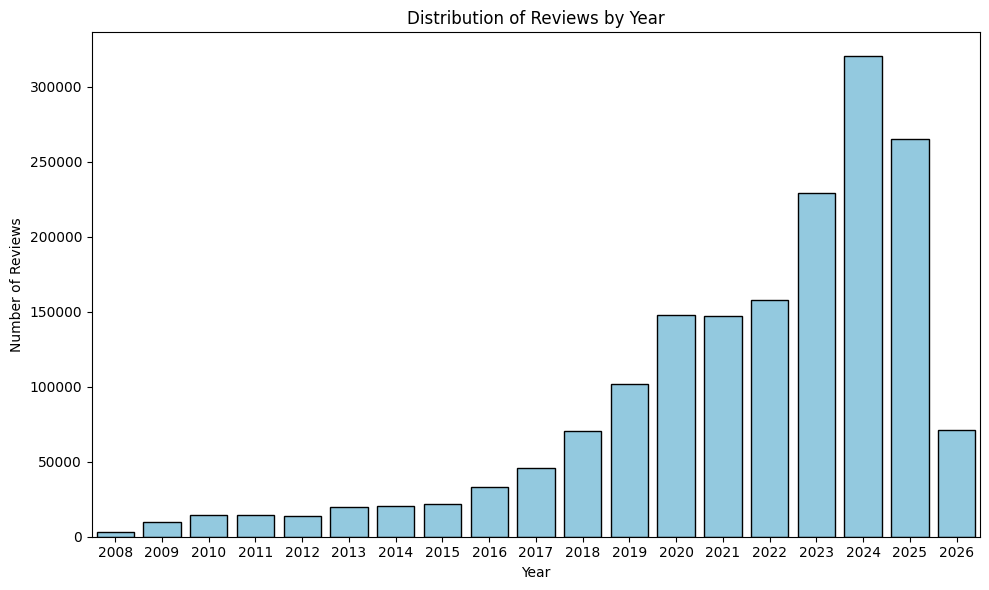

In [22]:
# Calculate the count of reviews by year
count_by_year = reviews_df['year'].value_counts().sort_index()
years = sorted(reviews_df['year'].unique())

# Plot the distribution of reviews by year
plt.figure(figsize=(10, 6))
sns.barplot(x=years, y=count_by_year[years], color='skyblue', edgecolor='black')
plt.title('Distribution of Reviews by Year')
plt.xlabel('Year')
plt.ylabel('Number of Reviews')

plt.tight_layout()
plt.show()

In [2]:
import pandas as pd
reviews_df = pd.read_csv("./data/sephora_skincare_reviews_stopwords_removed.csv")

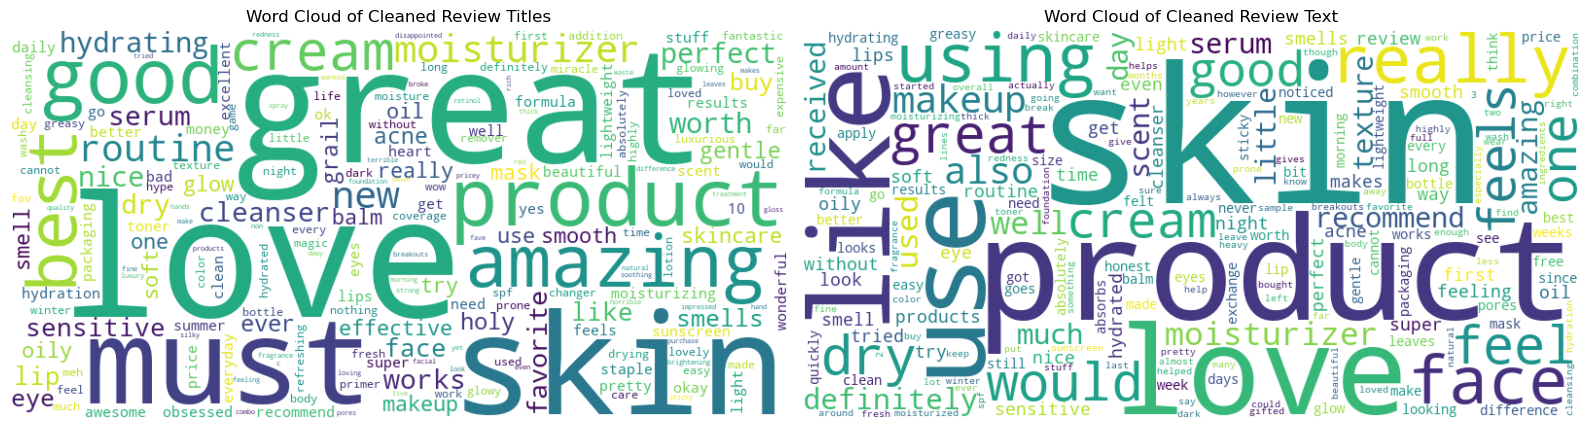

In [4]:
from wordcloud import WordCloud
from collections import Counter
import matplotlib.pyplot as plt

# Combine text
all_title_text   = ' '.join(reviews_df['cleaned_review_title'].dropna())
all_reviews_text = ' '.join(reviews_df['cleaned_review_text'].dropna())

# Word frequencies
title_freq   = Counter(all_title_text.split())
reviews_freq = Counter(all_reviews_text.split())

del title_freq['nan'] 

# Plot for word clouds
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, freq, title in zip(
    axes,
    [title_freq, reviews_freq],
    ['Word Cloud of Cleaned Review Titles', 'Word Cloud of Cleaned Review Text']):
    
    wc = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(freq)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title)

plt.tight_layout()
plt.show()

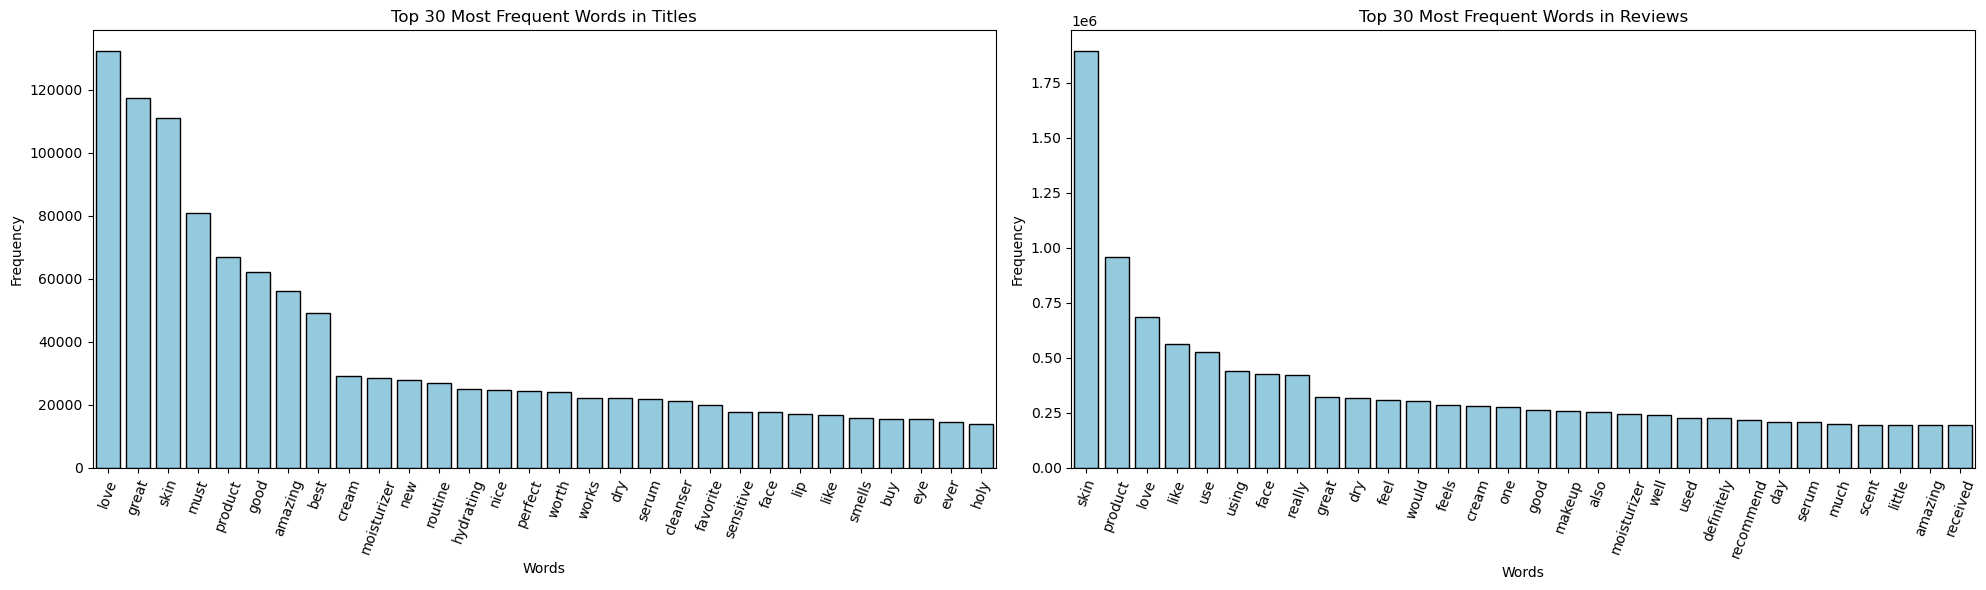

In [6]:
# Plot for bar charts of most common words
import seaborn as sns

most_com = 30
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

for ax, freq, title in zip(
    axes,
    [title_freq, reviews_freq],
    [f'Top {most_com} Most Frequent Words in Titles',
     f'Top {most_com} Most Frequent Words in Reviews']):
    
    words, counts = zip(*freq.most_common(most_com))
    sns.barplot(x=list(words), y=list(counts), ax=ax, color='skyblue', edgecolor='black')
    ax.set_xlabel('Words')
    ax.set_ylabel('Frequency')
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=70)

plt.tight_layout()
plt.show()

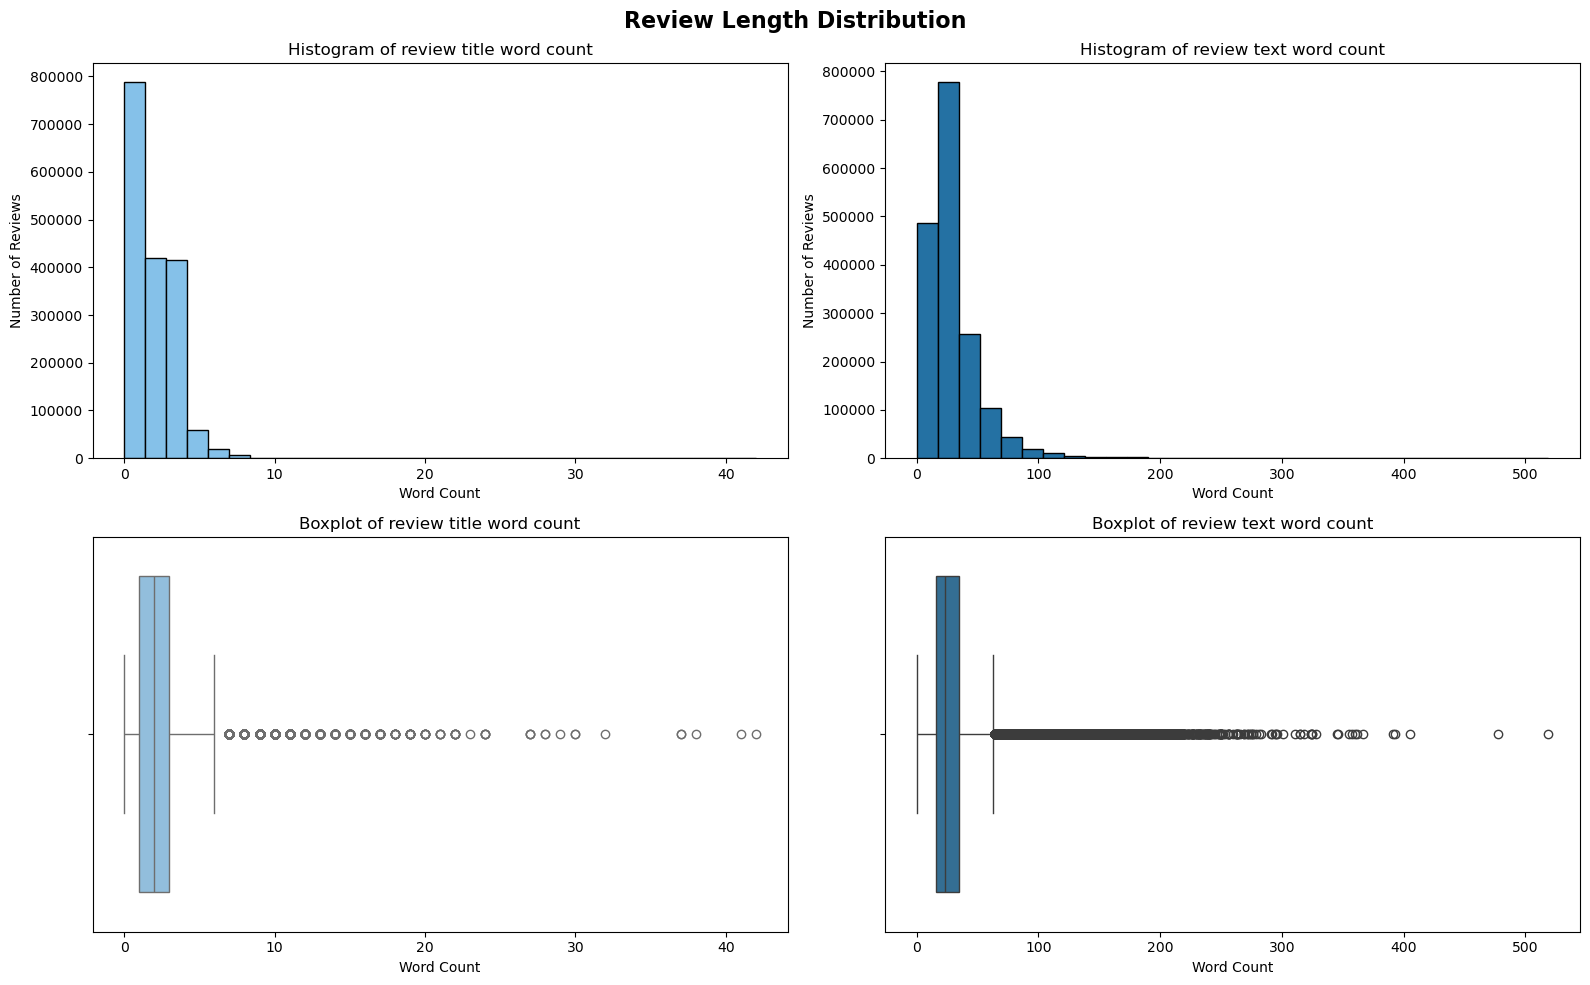

,Title Word Count,Review Word Count
count,1710285.0,1710285.0
mean,2.0,29.1
std,1.3,21.2
min,0.0,0.0
25%,1.0,16.0
50%,2.0,23.0
75%,3.0,35.0
max,42.0,519.0


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate word counts per review
reviews_df['title_word_count']  = reviews_df['cleaned_review_title'].dropna().apply(lambda x: len(str(x).split()))
reviews_df['review_word_count'] = reviews_df['cleaned_review_text'].dropna().apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Review Length Distribution', fontsize=16, fontweight='bold')

# Histogram: Title Word Count
axes[0, 0].hist(reviews_df['title_word_count'].dropna(), bins=30, color='#85C1E9', edgecolor='black')
axes[0, 0].set_title('Histogram of review title word count')
axes[0, 0].set_xlabel('Word Count')
axes[0, 0].set_ylabel('Number of Reviews')

# Histogram: Review Text Word Count
axes[0, 1].hist(reviews_df['review_word_count'].dropna(), bins=30, color='#2471A3', edgecolor='black')
axes[0, 1].set_title('Histogram of review text word count')
axes[0, 1].set_xlabel('Word Count')
axes[0, 1].set_ylabel('Number of Reviews')

# Boxplot: Title Word Count
sns.boxplot(x=reviews_df['title_word_count'].dropna(), ax=axes[1, 0], color='#85C1E9')
axes[1, 0].set_title('Boxplot of review title word count')
axes[1, 0].set_xlabel('Word Count')

# Boxplot: Review Text Word Count
sns.boxplot(x=reviews_df['review_word_count'].dropna(), ax=axes[1, 1], color='#2471A3')
axes[1, 1].set_title('Boxplot of review text word count')
axes[1, 1].set_xlabel('Word Count')

plt.tight_layout()
plt.show()

# Summary statistics for title and review word counts
summary_df = pd.DataFrame({
    'Title Word Count'  : reviews_df['title_word_count'].describe(),
    'Review Word Count' : reviews_df['review_word_count'].describe()
}).round(1)

summary_df

# 5. Topic modeling

In [4]:
# Import cleaned reviews to skip re-running the text preprocessing
import pandas as pd

clean_reviews_df = pd.read_csv("./data/sephora_review_chunks.csv")
cleaned_texts = clean_reviews_df['review_chunk'].tolist()

print(clean_reviews_df.shape)
pd.set_option('display.max_colwidth', None)
clean_reviews_df[clean_reviews_df['n_chunks']>1].iloc[:, :4].tail(6)

(2214276, 10)


,review_id,chunk_pos,n_chunks,review_chunk
2214248,381229512,0,2,"this is so powerful. i love how it just goes right on. and you can layer it, it smells. so good. and it also has the perfect blending experience. i cannot even explain how easily it blends into either light or dark skin. really? it gives you that perfect glow."
2214249,381229512,1,2,"it is not transferable, it is got a little bit of shine to it but it is definitely not glitter. it just gives you that summer glow and it looks so natural. does not look fake at all. it is so beautiful. it is easy to travel with easy to apply.it is the perfect on the go, everyday solution ."
2214250,381169861,0,2,"i am loving this product; it gives me the perfect contoured look. i sculpted my face with this product, and it gives the most natural look. i love waking up looking freshly tanned and warm."
2214251,381169861,1,2,"the application is super simple, and it lasts for up to days. there is also no need to wash off it will fade on its own, which i really like. i will definitely be repurchasing this item and recommending it to my friends. as someone who is light-skinned and losing color in the winter, this gives me a summer glowy tan all year round!"
2214252,380571286,0,2,"after using this product over the past few weeks, i am loving the results! it has made my makeup routine in the morning easier. application is easy, and the formula is smooth and smells nice."
2214253,380571286,1,2,i highly recommend it.


In [ ]:
### Generate sentence embeddings for topic modeling
import numpy as np
import torch
from sentence_transformers import SentenceTransformer

# Define embeddings model
device = 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'Device: {device}')

embeddings_model = SentenceTransformer('all-MiniLM-L6-v2', device=device)

# Generate embeddings and save to file to avoid re-computation
embeddings = embeddings_model.encode(cleaned_texts,
                                     show_progress_bar=True,
                                     batch_size=64)

np.save('embeddings.npy', embeddings)

Device: mps
Total clean texts without NaN: 1708523


Batches:   0%|          | 0/26696 [00:00<?, ?it/s]

In [ ]:
### Topic Modeling with BERTopic

import numpy as np
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

# Define UMAP model for dimensionality reduction
umap_model = UMAP(n_neighbors=100,            # tune to control the topic granularity (lower = more topics - local structure, higher = fewer topics - global structure)
                  n_components=5,             # dimensionality reduction for HDBSCAN clustering
                  min_dist=0.0,
                  metric='cosine',
                  random_state=42)

# Define HDBSCAN model for clustering
hdbscan_model = HDBSCAN(min_cluster_size=1000, # tune to control the minimum size of clusters (topics)
                        min_samples=50,        # tune to control the sensitivity to noise (lower = more clusters, higher = fewer clusters)
                        metric='euclidean', 
                        cluster_selection_method='eom', 
                        prediction_data=True)

# Define CountVectorizer for topic representation
vectorizer_model = CountVectorizer(ngram_range=(1, 2),    # to capture unigrams and bigrams topics
                                   stop_words='english',
                                   min_df=0.01)            # ignore words that appear in less than 20 documents

# Create BERTopic model
embeddings = np.load('embeddings.npy')
topic_model = BERTopic(umap_model=umap_model,
                       hdbscan_model=hdbscan_model,
                       vectorizer_model=vectorizer_model,
                       top_n_words=10,                    # number of words to represent each topic
                       nr_topics=None,
                       calculate_probabilities=True,
                       verbose=True)

topics, probabilities = topic_model.fit_transform(cleaned_texts, embeddings)
topic_model.save("bertopic_model")

# Reduce topics after fitting
topic_model.reduce_topics(cleaned_texts, nr_topics=100)

# Recompute probabilities after reduction
topics = topic_model.topics_
probabilities = topic_model.probabilities_

# Save the BERTopic model
topic_model.save("bertopic_model_reduced")

# Save the topic summary
topic_info = topic_model.get_topic_info()
topic_info.to_csv("topic_summary.csv", index=False)

# Save the document-topic assignments with all probabilities
docs_data = []

for i, doc in enumerate(cleaned_texts):
    prob_row = probabilities[i]
    main_topic = topics[i]
    main_prob = prob_row[main_topic] if main_topic != -1 else 0.0
    
    row = {
        "review_text": doc,
        "main_topic": main_topic,
        "main_prob": main_prob
    }
    
    docs_data.append(row)

docs_df = pd.DataFrame(docs_data)
prob_df = pd.DataFrame(probabilities, columns=[f"topic_{i}" for i in range(probabilities.shape[1])])
docs_df = pd.concat([docs_df, prob_df], axis=1)
docs_df.to_csv("reviews_with_probs.csv", index=False)

/home/desy/miniconda3/envs/desyenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-05 10:23:29,326 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-05 12:32:25,714 - BERTopic - Dimensionality - Completed ✓
2026-04-05 12:32:25,746 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-05 13:33:34,052 - BERTopic - Cluster - Completed ✓
2026-04-05 13:33:34,295 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-05 13:34:53,471 - BERTopic - Representation - Completed ✓
2026-04-05 13:35:05,445 - BERTopic - Topic reduction - Reducing number of topics
2026-04-05 13:35:06,247 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-05 13:36:32,588 - BERTopic - Representation - Completed ✓
2

In [12]:
from bertopic import BERTopic

topic_model = BERTopic.load("bertopic_model")

/home/desy/miniconda3/envs/desyenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
from IPython.display import HTML

# Display the dendrogram (hierarchical clustering of topics)
topic_model.reduce_topics(cleaned_texts, nr_topics=100)
hierarchical_topics = topic_model.hierarchical_topics(cleaned_texts)
fig = topic_model.visualize_hierarchy(hierarchical_topics = hierarchical_topics)
fig.write_html("topic_dendrogram.html")

fig_html = fig.to_html(full_html=False)
display(HTML(fig_html))

100%|██████████| 98/98 [00:11<00:00,  8.67it/s]


In [4]:
topic_model.reduce_topics(cleaned_texts, nr_topics=100)
hierarchical_topics = topic_model.hierarchical_topics(cleaned_texts)
fig = topic_model.visualize_hierarchy(hierarchical_topics = hierarchical_topics)
fig.write_image("topic_dendrogram.png", width=1600, height=900, scale=2)

100%|██████████| 48/48 [00:07<00:00,  6.45it/s]


# 6. Aspect-Based Sentiment Analysis

In [2]:
# Sample from the df
sample_df = clean_reviews_df.sample(n=200, random_state=42)  
reviews = sample_df["review_chunk"].tolist()
print(f"Total inference calls: {len(reviews) * 10}") # 10 aspects

Total inference calls: 2000


In [ ]:
from src.absa_model import load_model, run_inference

absa_model = load_model()
results_df = run_inference(absa_model, reviews, threshold=0.5)
results_df.head()

### Generate samples for manually labelled dataset

In [ ]:
# Import the reviews with assigned topics from BERTopic results
import pandas as pd
topics_df = pd.read_csv("reviews_with_probs.csv")

In [116]:
### Define topic to aspect mapping from BERTopic results

topic_to_aspect = {
    # Acne & Blemish Control
    9: "Acne & Blemish Control", 
    78: "Acne & Blemish Control", 92: "Acne & Blemish Control",
    98: "Acne & Blemish Control",
    # Anti-Aging & Skin Renewal
    6: "Anti-Aging & Skin Renewal", 25: "Anti-Aging & Skin Renewal",
    26: "Anti-Aging & Skin Renewal", 77: "Anti-Aging & Skin Renewal",
    95: "Anti-Aging & Skin Renewal",
    # Cleansing & Exfoliation
    3: "Cleansing & Exfoliation", 10: "Cleansing & Exfoliation",
    24: "Cleansing & Exfoliation", 61: "Cleansing & Exfoliation",
    66: "Cleansing & Exfoliation",
    # Consistency & Texture
    62: "Consistency & Texture", 49: "Consistency & Texture",
    2: "Consistency & Texture",  35: "Consistency & Texture",
    57: "Consistency & Texture", 79: "Consistency & Texture",
    80: "Consistency & Texture", 63: "Consistency & Texture",
    34: "Consistency & Texture", 76: "Consistency & Texture",
    # Hydration & Moisturization
    4: "Hydration & Moisturization", 11: "Hydration & Moisturization",
    0: "Hydration & Moisturization", 12: "Hydration & Moisturization",
    16: "Hydration & Moisturization", 42: "Hydration & Moisturization",
    82: "Hydration & Moisturization", 94: "Hydration & Moisturization",
    1: "Hydration & Moisturization",
    # Packaging & Size
    22: "Packaging & Size", 27: "Packaging & Size", 40: "Packaging & Size",
    41: "Packaging & Size", 51: "Packaging & Size", 74: "Packaging & Size",
    81: "Packaging & Size", 70: "Packaging & Size", 50: "Packaging & Size",
    53: "Packaging & Size",
    # Skin Sensitivity
    7: "Skin Sensitivity", 
    # Skin Tone & Pigmentation
    5: "Skin Tone & Pigmentation", 29: "Skin Tone & Pigmentation",
    54: "Skin Tone & Pigmentation",
    # Sun Protection
    8: "Sun Protection", 52: "Sun Protection",
    # Wear & Longevity
    97: "Wear & Longevity", 55: "Wear & Longevity",
    65: "Wear & Longevity", 84: "Wear & Longevity",
}

aspect_df = topics_df[['review_id', 'year', 'main_topic', 'rating', 'cleaned_review_text', 'cleaned_demojize_review_text', 'cleaned_review_title']].copy()
aspect_df["aspect"] = aspect_df["main_topic"].map(topic_to_aspect)
aspect_df = aspect_df[aspect_df["aspect"].notna()].copy()

cols = list(aspect_df.columns)
cols.insert(1, cols.pop(cols.index('aspect')))
aspect_df = aspect_df[cols]

# Save aspect_df for further analysis
aspect_df.to_csv("reviews_aspect_df.csv", index=False)

In [ ]:
### Stratified sampling for ABSA labelling
from src.data_sampling import sample_for_manually_labelled_set

sample_df = sample_for_manually_labelled_set(aspect_df, text_col="cleaned_review_text", n_per_aspect=410, seed=42)

Total samples : 4070

Samples per aspect per year:
year                        2016  2017  2018  2019  2020  2021  2022  2023  2024  2025  2026
aspect                                                                                      
Acne & Blemish Control        37    37    37    37    37    37    37    37    37    37    37
Anti-Aging & Skin Renewal     37    37    37    37    37    37    37    37    37    37    37
Cleansing & Exfoliation       37    37    37    37    37    37    37    37    37    37    37
Consistency & Texture         37    37    37    37    37    37    37    37    37    37    37
Hydration & Moisturization    37    37    37    37    37    37    37    37    37    37    37
Packaging & Size              37    37    37    37    37    37    37    37    37    37    37
Skin Sensitivity              37    37    37    37    37    37    37    37    37    37    37
Skin Tone & Pigmentation      37    37    37    37    37    37    37    37    37    37    37
Sun Protection     

### Import manually labelled dataset

In [ ]:
import pandas as pd

manual_label_df = pd.read_excel("data/absa_labelling_sample_with_labels.xlsx")
manual_label_df.head(3)

,review_id,aspect,year,main_topic,rating,cleaned_review_text,cleaned_demojize_review_text,cleaned_review_title,sentiment_labels
0,58645662,Acne & Blemish Control,2016,9,4,what is interesting is i bought this product t...,what is interesting is i bought this product t...,pores no more,positive
1,77914685,Acne & Blemish Control,2016,9,5,this literally just came in the mail hours ago...,this literally just came in the mail hours ago...,amazingggggg,positive
2,61158497,Acne & Blemish Control,2016,9,5,no more breakouts! give it time and you will s...,no more breakouts! give it time and you will s...,love it,positive


In [ ]:
manual_label_df.groupby(['aspect','sentiment_labels']).size().unstack(fill_value=0)

sentiment_labels,negative,neutral,not_mentioned,positive
aspect,,,,
Acne & Blemish Control,62,24,9,312
Anti-Aging & Skin Renewal,33,9,133,232
Cleansing & Exfoliation,33,9,30,335
Consistency & Texture,88,19,32,268
Hydration & Moisturization,15,17,71,304
Packaging & Size,78,30,40,259
Skin Sensitivity,81,19,18,289
Skin Tone & Pigmentation,31,7,160,209
Sun Protection,35,27,8,337


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5239.00it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/home/desy/miniconda3/envs/desyenv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Text(0.5, 1.0, 'Distribution by Sentiment Labels')

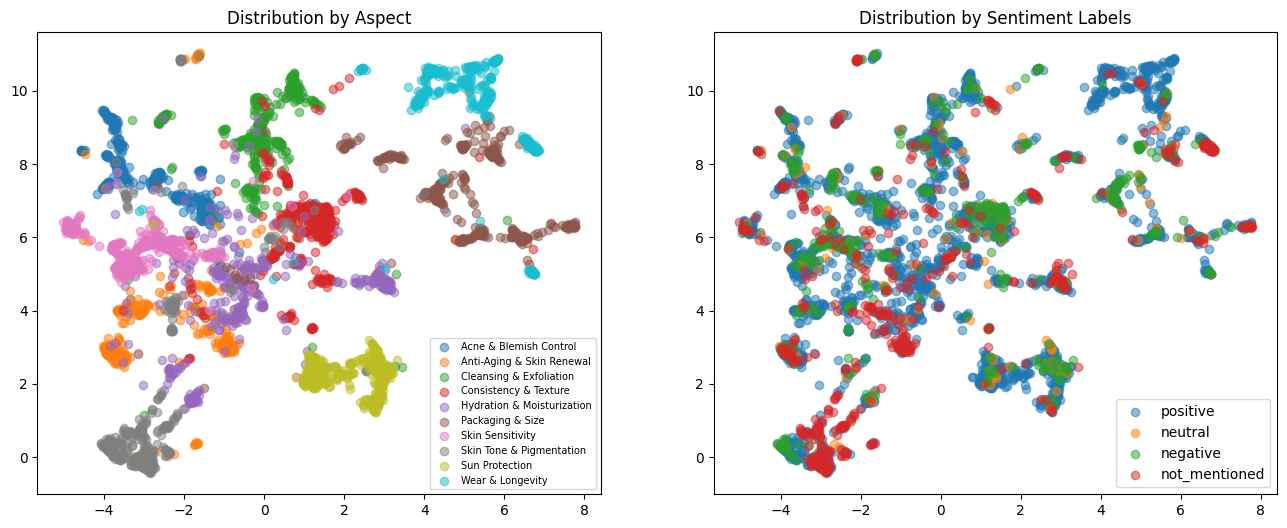

<Figure size 1200x800 with 0 Axes>

In [4]:
### UMAP Visualizationt for quality checking the manual labels

from sentence_transformers import SentenceTransformer
import umap
import matplotlib.pyplot as plt

model     = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(manual_label_df["cleaned_review_text"].tolist())

reducer   = umap.UMAP(random_state=42)
embedding_2d = reducer.fit_transform(embeddings)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plt.figure(figsize=(12, 8))

# Plot by aspect
for aspect in manual_label_df["aspect"].unique():
    mask = manual_label_df["aspect"] == aspect
    axes[0].scatter(embedding_2d[mask, 0], embedding_2d[mask, 1], label=aspect, alpha=0.5)
axes[0].legend(fontsize=7)
axes[0].set_title("Distribution by Aspect")

# Plot by label
for label in manual_label_df["sentiment_labels"].unique():
    mask = manual_label_df["sentiment_labels"] == label
    axes[1].scatter(embedding_2d[mask, 0], embedding_2d[mask, 1], label=label, alpha=0.5)
axes[1].legend()
axes[1].set_title("Distribution by Sentiment Labels")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5895.86it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


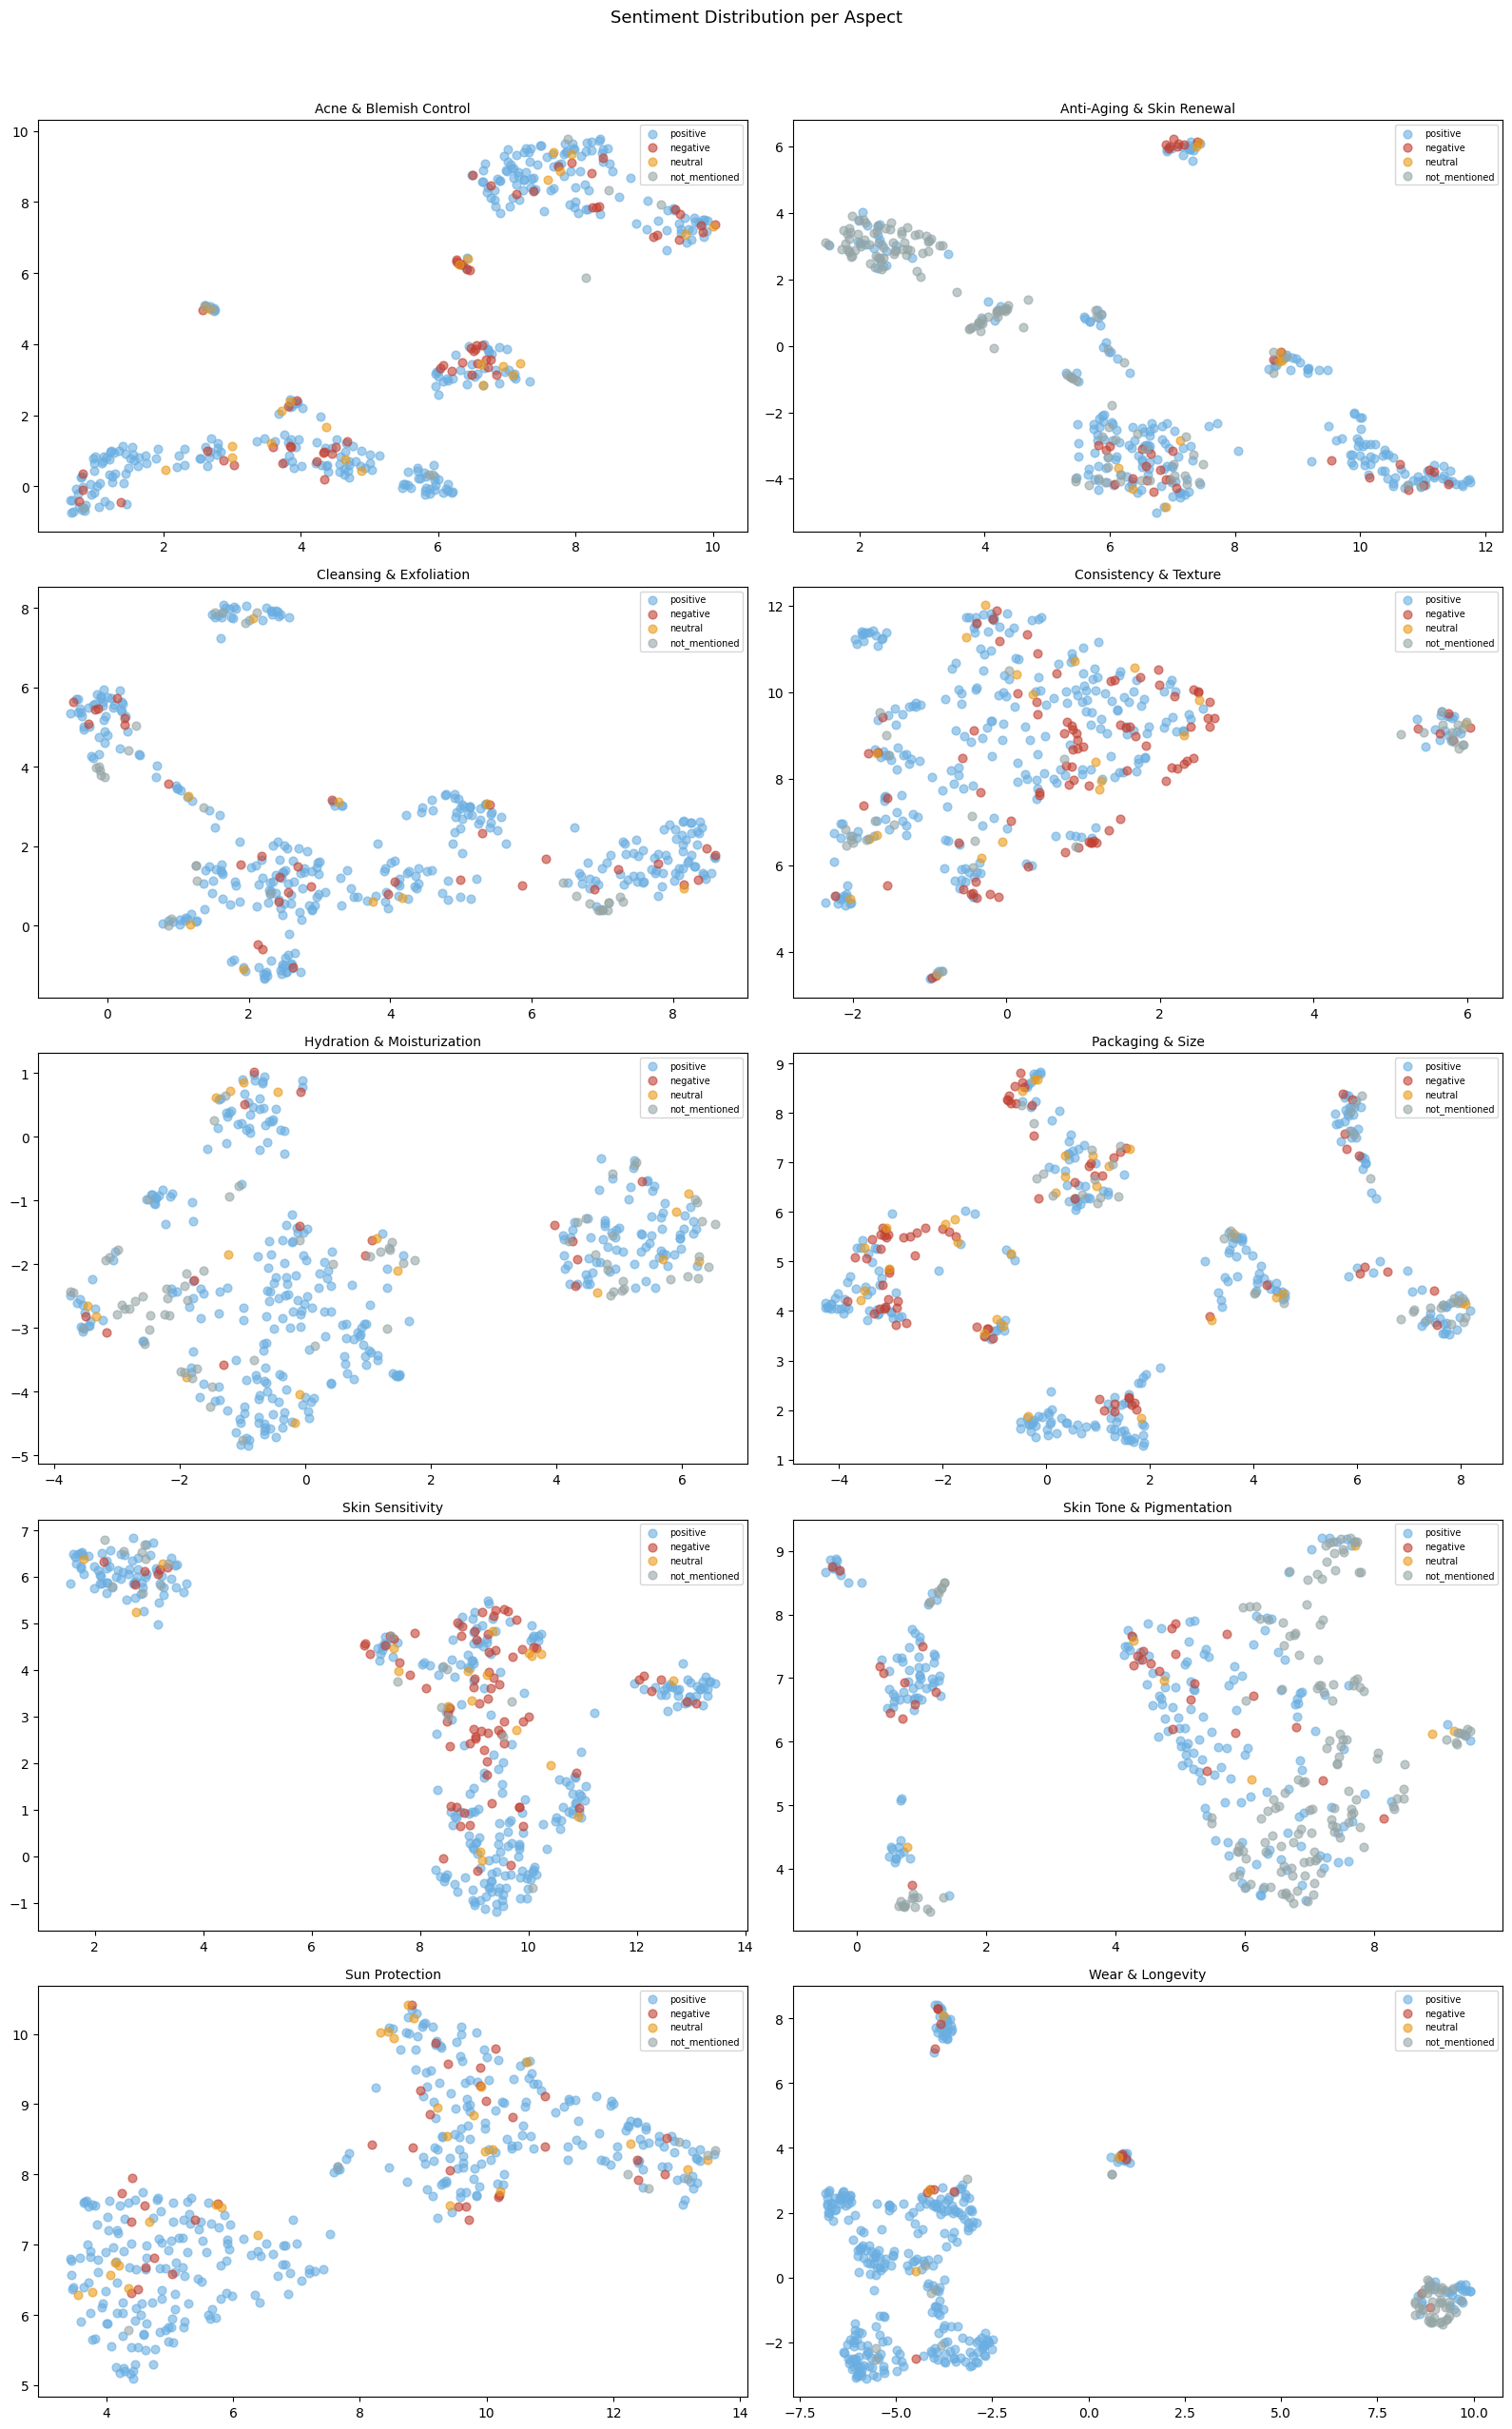

In [26]:
import umap
import matplotlib.pyplot as plt
import pandas as pd
from sentence_transformers import SentenceTransformer
import warnings
import logging

# Suppress umap warnings
warnings.filterwarnings("ignore")
logging.getLogger("sentence_transformers").setLevel(logging.ERROR)

model = SentenceTransformer("all-MiniLM-L6-v2")

sentiment_colors = {
    "positive"      : "#6aaee1",  
    "negative"      : "#c24032",  
    "neutral"       : "#ea9a19",  
    "not_mentioned" : "#95a5a6" 
}

aspects = manual_label_df["aspect"].unique()
n_cols  = 2
n_rows  = (len(aspects) + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 5))
axes = axes.flatten()

for i, aspect in enumerate(aspects):
    aspect_df = manual_label_df[manual_label_df["aspect"] == aspect].copy()

    # Encode only one aspect texts
    embeddings = model.encode(aspect_df["cleaned_review_text"].tolist())

    # UMAP per aspect
    reducer      = umap.UMAP(random_state=42, n_neighbors=15, min_dist=0.1)
    embedding_2d = reducer.fit_transform(embeddings)

    for label, color in sentiment_colors.items():
        mask = aspect_df["sentiment_labels"] == label
        axes[i].scatter( embedding_2d[mask, 0], embedding_2d[mask, 1], label = label, color = color, alpha = 0.6, s = 40)

    axes[i].set_title(aspect, fontsize=10)
    axes[i].legend(fontsize=7)

# Hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Sentiment Distribution per Aspect", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [2]:
# Targets to achieve 280 positives, 100 negatives, 80 neutrals, and 100 not_mentioned per aspect
from src.data_sampling import run_targeted_resampling

targets = {
    "Acne & Blemish Control"     : {"negative": 38,  "neutral": 56, "not_mentioned": 91,  "positive": 280},
    "Anti-Aging & Skin Renewal"  : {"negative": 67,  "neutral": 71, "not_mentioned": 0,   "positive": 280}, 
    "Cleansing & Exfoliation"    : {"negative": 67,  "neutral": 71, "not_mentioned": 70,  "positive": 280},
    "Consistency & Texture"      : {"negative": 12,  "neutral": 61, "not_mentioned": 68,  "positive": 280},
    "Hydration & Moisturization" : {"negative": 85,  "neutral": 63, "not_mentioned": 29,  "positive": 280},
    "Packaging & Size"           : {"negative": 22,  "neutral": 50, "not_mentioned": 60,  "positive": 280},
    "Skin Sensitivity"           : {"negative": 19,  "neutral": 61, "not_mentioned": 82,  "positive": 280},
    "Skin Tone & Pigmentation"   : {"negative": 69,  "neutral": 73, "not_mentioned": 0,   "positive": 280},
    "Sun Protection"             : {"negative": 65,  "neutral": 53, "not_mentioned": 92,  "positive": 280},
    "Wear & Longevity"           : {"negative": 86,  "neutral": 76, "not_mentioned": 50,  "positive": 280},
}


updated_labelled_df, resample_df, augment_df = run_targeted_resampling(aspect_df, manual_label_df, targets, seed=42)


Saved 1512 samples needing manual labelling
Saved 347 neutral samples with augmentation
